✅ R² Score: 0.5901640114324174
Mean Squared Error: 164892511921091.47


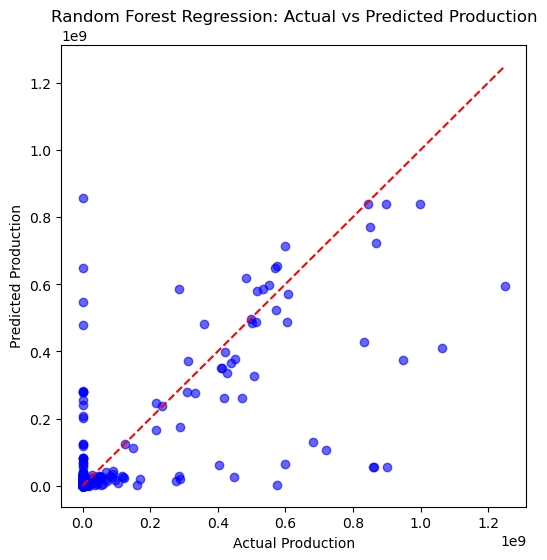

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# -----------------------------
# 1. Load dataset
# -----------------------------
df = pd.read_csv(r"C:\Users\poova\Machine Learning\crop_production.csv")

# -----------------------------
# 2. Features and target
# -----------------------------
X = df[['Crop', 'Area']]
X = pd.get_dummies(X, columns=['Crop'], drop_first=True)  # One-Hot Encoding
y = pd.to_numeric(df['Production'], errors='coerce')

# Drop NaN values
mask = y.notna()
X, y = X.loc[mask], y.loc[mask]

# -----------------------------
# 3. Train-test split
# -----------------------------
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# -----------------------------
# 4. Train Random Forest Regressor
# -----------------------------
rf_reg = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_reg.fit(x_train, y_train)

# -----------------------------
# 5. Predictions & Accuracy
# -----------------------------
y_pred = rf_reg.predict(x_test)

print("✅ R² Score:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

# -----------------------------
# 6. Visualization
# -----------------------------
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # perfect fit line
plt.title("Random Forest Regression: Actual vs Predicted Production")
plt.xlabel("Actual Production")
plt.ylabel("Predicted Production")
plt.show()
